In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words=open("fiction_clean.txt", "r", encoding="utf-8").read().splitlines()

In [3]:
len(words)

5403

In [4]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['<S>']=0;
itos={i:s for s,i in stoi.items()}
print(itos)

{1: ' ', 2: '!', 3: '"', 4: '&', 5: "'", 6: ',', 7: '-', 8: '.', 9: '0', 10: '1', 11: '2', 12: '3', 13: '4', 14: '5', 15: '6', 16: '7', 17: '8', 18: '9', 19: ':', 20: ';', 21: '?', 22: 'A', 23: 'B', 24: 'C', 25: 'D', 26: 'E', 27: 'F', 28: 'G', 29: 'H', 30: 'I', 31: 'J', 32: 'K', 33: 'L', 34: 'M', 35: 'N', 36: 'O', 37: 'P', 38: 'Q', 39: 'R', 40: 'S', 41: 'T', 42: 'U', 43: 'V', 44: 'W', 45: 'X', 46: 'Y', 47: 'Z', 48: 'a', 49: 'b', 50: 'c', 51: 'd', 52: 'e', 53: 'f', 54: 'g', 55: 'h', 56: 'i', 57: 'j', 58: 'k', 59: 'l', 60: 'm', 61: 'n', 62: 'o', 63: 'p', 64: 'q', 65: 'r', 66: 's', 67: 't', 68: 'u', 69: 'v', 70: 'w', 71: 'x', 72: 'y', 73: 'z', 0: '<S>'}


In [5]:
x = []
y = []
block_size=3
for w in words:
    context = [0] * block_size

    for ch in list(w) + ['<S>']:
        ix = stoi[ch]

        x.append(context)
        y.append(ix)

        context = context[1:] + [ix]
x = torch.tensor(x)
y = torch.tensor(y)

In [6]:
x.shape,y.shape

(torch.Size([138481, 3]), torch.Size([138481]))

In [7]:
def build_dataset(words):
   block_size=3;
   x,y=[],[]
   for w in words:
        #print(w)
    context=[0]*block_size
    for ch in list(w) +['<S>']:
      ix=stoi[ch]
      x.append(context)
      y.append(ix)
     # print(''.join(itos[i] for i in context), '--->',itos[ix])
      context=context[1:] +[ix]

   x=torch.tensor(x)
   y=torch.tensor(y)
   print(x.shape,y.shape)
   return x,y
import random
random.seed(1234)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
xtr,ytr=build_dataset(words[:n1])
xdev,ydev=build_dataset(words[n1:n2])
xte,yte=build_dataset(words[n2:])


torch.Size([111298, 3]) torch.Size([111298])
torch.Size([13688, 3]) torch.Size([13688])
torch.Size([13495, 3]) torch.Size([13495])


In [8]:
c=torch.randn((len(itos),2)) #each char has 2dim representation



In [9]:
emb=c[x] # all the integers in x has an embedding in emb
emb.shape # each of the integer in this 135*3 matrix has its embedding to feed it onto network

torch.Size([138481, 3, 2])

In [10]:
w1=torch.randn((6,100)) # 100 neurons and 6 inputs to that layer (3*2)
b1=torch.randn(100)

In [11]:
 torch.cat(torch.unbind(emb,1),1).shape# unbind-map across all of dim 1 on embed-0,1,2 torch.cat([emb[:,0,:],emb[:,0,:],emb[:,0,:]],1).shape making it into 6 dim input instead of 3*2 for matrix mult

torch.Size([138481, 6])

In [12]:
h=torch.tanh(emb.view(emb.shape[0],6)@w1+b1) # instead of cat using view without any new storage

In [13]:
h.shape



torch.Size([138481, 100])

In [14]:
w2=torch.randn((100,len(itos)))
b2=torch.randn(len(itos)) # for second layer of nn

In [15]:
logits=h@w2+b2
logits.shape

torch.Size([138481, 74])

In [16]:
counts=logits.exp()

In [17]:
prob=counts/counts.sum(1,keepdims=True)

In [18]:
loss=-prob[torch.arange(logits.shape[0]),y].log().mean()
loss

tensor(22.4760)

In [37]:
g=torch.Generator().manual_seed(2345)
n_hidden=300
embed_dim=15
c=torch.randn((len(itos),embed_dim),generator=g)*0.1
w1=torch.randn((30,n_hidden),generator=g)*0.01
b1=torch.randn(n_hidden,generator=g)*0.01
w2=torch.randn((n_hidden,len(itos)),generator=g)*0.01
b2=torch.randn(len(itos),generator=g) *0
bngain=torch.ones((1,n_hidden))
bnbias=torch.zeros((1,n_hidden))
bnmean_running=torch.zeros((1,n_hidden))
bnstd_running=torch.ones((1,n_hidden))
params=[c,w1,b1,w2,b2,bngain,bnbias]

In [26]:
sum(p.nelement() for p in params)

22214

In [41]:
for p in params:
  p.requires_grad=True

In [42]:
hpreact.mean(0,keepdim=True).shape

torch.Size([1, 200])

In [43]:
steps=[]
losses=[]
batch_size=64
learning_rate=0.05
num_iterations=70000

for k in range(num_iterations):
  if k > 0 and k % 25000 == 0:
    learning_rate *= 0.5

  ix=torch.randint(0,xtr.shape[0],(batch_size,),generator=g)
  xb,yb=xtr[ix],ytr[ix]
  #forward pass
  emb=c[xb] 
  embcat=emb.view(emb.shape[0],-1)
  hpreact=embcat@w1+b1
  bnmeani=hpreact.mean(0,keepdim=True)
  bnstdi=hpreact.std(0,keepdim=True)
  hpreact=bngain*(hpreact-bnmeani)/(bnstdi+1e-5)+bnbias
  with torch.no_grad():
      bnmean_running=0.999*bnmean_running+0.001*bnmeani
      bnstd_running=0.999*bnstd_running+0.001*bnstdi
      
  h=torch.tanh(hpreact)
  logits=h@w2+b2
  loss=F.cross_entropy(logits,yb)
    
  for p in params:
    p.grad=None
  loss.backward()
  for p in params:
    p.data+=-learning_rate*p.grad
  steps.append(k)
  losses.append(loss.log10().item())

  if k % 20000 == 0:
    print(f"step {k:>6d} | loss {loss.item():.4f} | lr {learning_rate:.5f}")

print(f"Final loss: {loss.item():.4f}")

1.903330683708191


In [1]:
1/74

0.013513513513513514

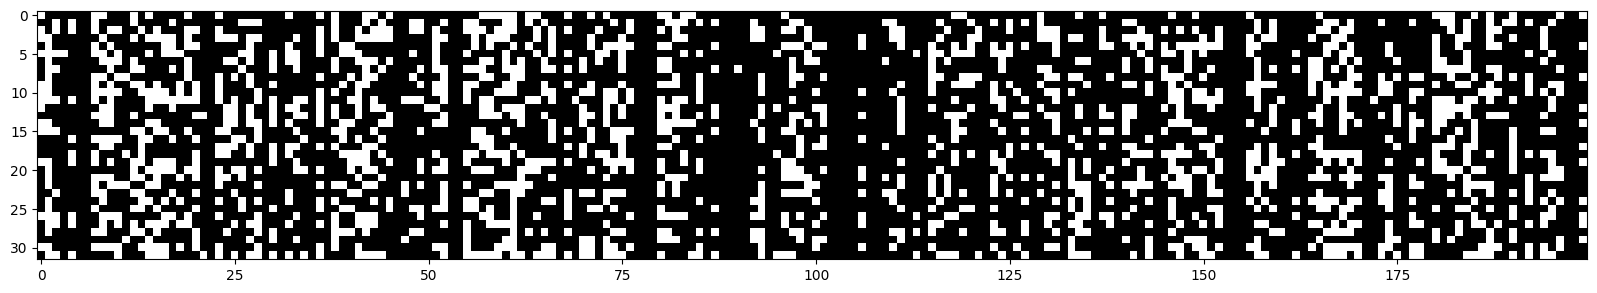

In [85]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap='gray',interpolation='nearest')

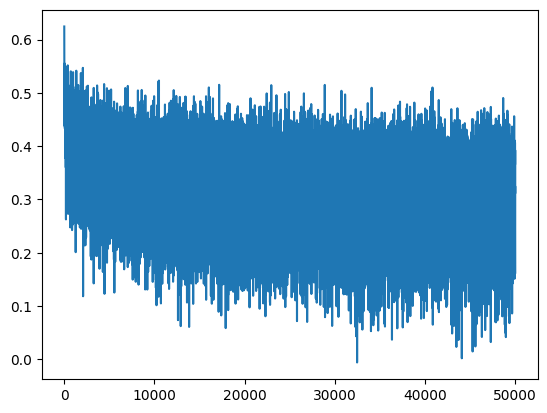

In [48]:
plt.plot(steps,losses)

In [44]:
@torch.no_grad()
def split_loss(split):
 x,y={
    'train':(xtr,ytr),
    'val':(xdev,ydev),
    'test':(xte,yte)
 }[split]
 emb=c[x]
 embcat=emb.view(emb.shape[0],-1)
 hpreact=embcat@w1+b1
 hpreact=bngain*(hpreact-bnmean_running)/bnstd_running +bnbias
 h=torch.tanh(hpreact)
 logits=h@w2+b2
 loss=F.cross_entropy(logits,y)
 print(split,loss.item())

split_loss('train')
split_loss('val')

train 1.9404668807983398
val 2.0277161598205566


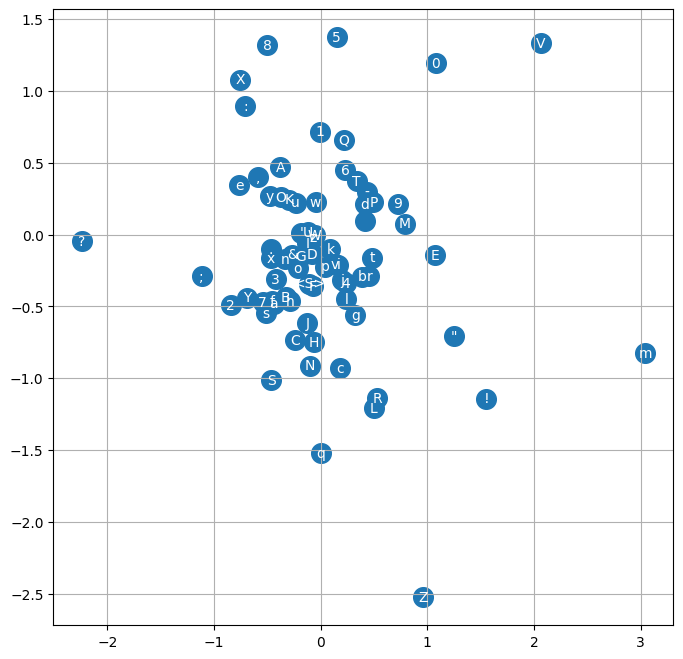

In [419]:

plt.figure(figsize=(8,8))
plt.scatter(c[:,0].data,c[:,1].data,s=200)
for i in range(c.shape[0]):
    plt.text(c[i,0].item(),c[i,1].item(),itos[i],ha="center",va="center",color="white")
plt.grid('minor')


In [32]:
g = torch.Generator().manual_seed(678)

for _ in range(20):

    out = []
    context = [0] * block_size

    while True:

        emb = c[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ w1 + b1)
        logits = h @ w2 + b2
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(
            probs,
            num_samples=1,
            generator=g
        ).item()

        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out[:-1]))

OundeschVurpux
Fromler
Robean Hund-Twomes Expegkivelpti
Yeopiz
Mromet:
ToxpripithNphets7
Cetenzin;s Wargerhexplet' Pereath
Appsuthe Ijmpirgess
Lrenda cottitrapenitinver-SthingDlume Endemplanet2bs5.
Norpatparylue Grketthnegndeak?
Brolixinhmpllogry
CegablepletientchVas!?
Hentheraschetsencand Cry Birg Hoggerot
Roghtelijebitkippitztchelematgda
Zllevasteon
Fordseks
The ExpyrcgtondJUthet
Rean
Riopirond
Drpatannells Bralkr


In [ ]:
#batch normalization here might not bring major changes but wuth nn with many hidden layers it brings a lot of change
